# Background detection — sample spectrograms

A first look at the preprocessor HDF5 backing the DCLDE 2027 background-detection work:
`data/smoke/preprocessor/4913cc3a0a44238c_20260904_102331.h5` (MLflow run `d0c327aa83fa43fabf84474ee43d5bac`,
`preprocessor.run_name = smoke_pcen_power2_test`).

This is the 855-row smoke subset, built with `preprocessor.spectrogram.mel.power = 2.0` (the fix for
the `dynamic: pcen` config bug found while inspecting `a9e142b8dabed91f_20260901_063130.h5` — PCEN's
AGC expects a power spectrogram, not amplitude). Use this notebook to sanity-check the fix before
rebuilding the full `dclde_2027_kpalmer_full` dataset.

Every row is one 5 s clip: a 160-bin mel spectrogram (PCEN dynamic range, `sr = 32 kHz`, `hop = 320`)
plus the annotation metadata it came from. The `Background` rows are the naive negatives
(`BackgroundMethod = naive`); everything else is a real annotation.

Below: the label distribution, a stratified grid (every class side by side), and a purely random
draw (the class mix a detector actually sees).

In [1]:
from pathlib import Path
import pickle

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa

BASE     = Path("/home/noah/HALLO_encoder_collection")
H5_PATH  = BASE / "data/smoke/preprocessor/4913cc3a0a44238c_20260904_102331.h5"
CFG_PATH = BASE / "data/smoke/preprocessor/d0c327aa83fa43fabf84474ee43d5bac/spectrogram_config.pkl"
SR = 32_000  # preprocessor.audio_file.resample_sr logged for this run

spec_config = pickle.loads(CFG_PATH.read_bytes())
HOP = spec_config.stft.hop_length
MEL_HZ = librosa.mel_frequencies(
    n_mels=spec_config.mel.n_mels, fmin=spec_config.mel.fmin, fmax=spec_config.mel.fmax, htk=spec_config.mel.htk,
)

rng = np.random.default_rng(0)
pd.set_option("display.width", 160)

print(spec_config)

stft=STFTConfig(n_fft=1024, hop_length=320, win_length=640, window='hann', center=True, pad_mode='constant') freq_scale='mel' mag=MagConfig(power=1.0) mel=MelConfig(n_mels=160, fmin=50.0, fmax=16000.0, htk=False, norm='slaney', power=2.0) dynamic='pcen' db=DbConfig(ref=1.0, amin=1e-10, top_db=80.0) pcen=PcenConfig(gain=0.8, bias=0.01, power=0.25, time_constant=1.0, eps=1e-06)


## 1 · What's in the file

In [2]:
h5 = h5py.File(H5_PATH, "r")

META_COLS = ["uid", "Labels", "Dataset", "BackgroundMethod", "AnnotationLevel", "CallType",
             "Soundfile", "FileBeginSec", "Duration", "LowFreqHz", "HighFreqHz"]

def read_col(name):
    """Whole metadata column as a numpy array, decoded if it is a string dataset."""
    dset = h5[name]
    return dset.asstr()[:] if h5py.check_string_dtype(dset.dtype) else dset[:]

meta = pd.DataFrame({c: read_col(c) for c in META_COLS})

print(f"rows          : {len(meta):>9,}")
print(f"spec          : {h5['spec'].shape}  {h5['spec'].dtype}   "
      f"({h5['spec'].shape[2] * HOP / SR:.2f} s x {h5['spec'].shape[1]} mel bins)")
print(f"datasets      : {meta['Dataset'].nunique()}")
print()
print(pd.crosstab(meta["Labels"], meta["BackgroundMethod"], margins=True))

rows          :       845
spec          : (845, 160, 501)  float64   (5.01 s x 160 mel bins)
datasets      : 27

BackgroundMethod  naive  nan  All
Labels                           
AB                    0   85   85
Background           90    0   90
HW                    0   90   90
KW_und                0   89   89
NRKW                  0   90   90
OKW                   0   89   89
SAR                   0   45   45
SRKW                  0   90   90
TKW                   0   88   88
UndBio                0   89   89
All                  90  755  845


## 2 · Plot helpers

In [3]:
def read_specs(indices):
    """Spectrograms for arbitrary row indices; h5py fancy indexing needs them sorted."""
    indices = np.asarray(indices)
    order = np.argsort(indices)
    specs = h5["spec"][indices[order]]
    return specs[np.argsort(order)]


def plot_grid(indices, n_cols=4, title=None, tick_khz=(0.1, 1, 4, 16)):
    """Grid of spectrograms, one panel per row index, titled with its label and uid."""
    specs = read_specs(indices)
    rows = meta.iloc[list(indices)]
    n_rows = int(np.ceil(len(indices) / n_cols))
    seconds = specs.shape[2] * HOP / SR
    yticks = [int(np.abs(MEL_HZ - khz * 1000).argmin()) for khz in tick_khz]

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.4 * n_cols, 2.5 * n_rows), squeeze=False)
    for ax, spec, (_, row) in zip(axes.ravel(), specs, rows.iterrows()):
        vmin, vmax = np.percentile(spec, [1, 99])
        ax.imshow(spec, origin="lower", aspect="auto", cmap="magma")
        ax.set_title(f"{row.Labels}  ·  uid {row.uid}\n{row.Dataset}", fontsize=9)
        ax.set_yticks(yticks, [f"{k:g}" for k in tick_khz], fontsize=7)
        ax.tick_params(axis="x", labelsize=7)
    for ax in axes.ravel()[len(indices):]:
        ax.axis("off")
    for ax in axes[-1]:
        ax.set_xlabel("s", fontsize=8)
    for ax in axes[:, 0]:
        ax.set_ylabel("kHz", fontsize=8)
    if title:
        fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    return fig

## 3 · One row per class

Four random clips from each label, `Background` first — the negatives the detector has to separate
from everything below them. The smoke subset carries all 10 raw labels (the full `dclde_2027_kpalmer_full`
run only keeps 6, after `classes_to_drop` removes `NRKW`/`OKW`/`KW_und`/`SAR`).

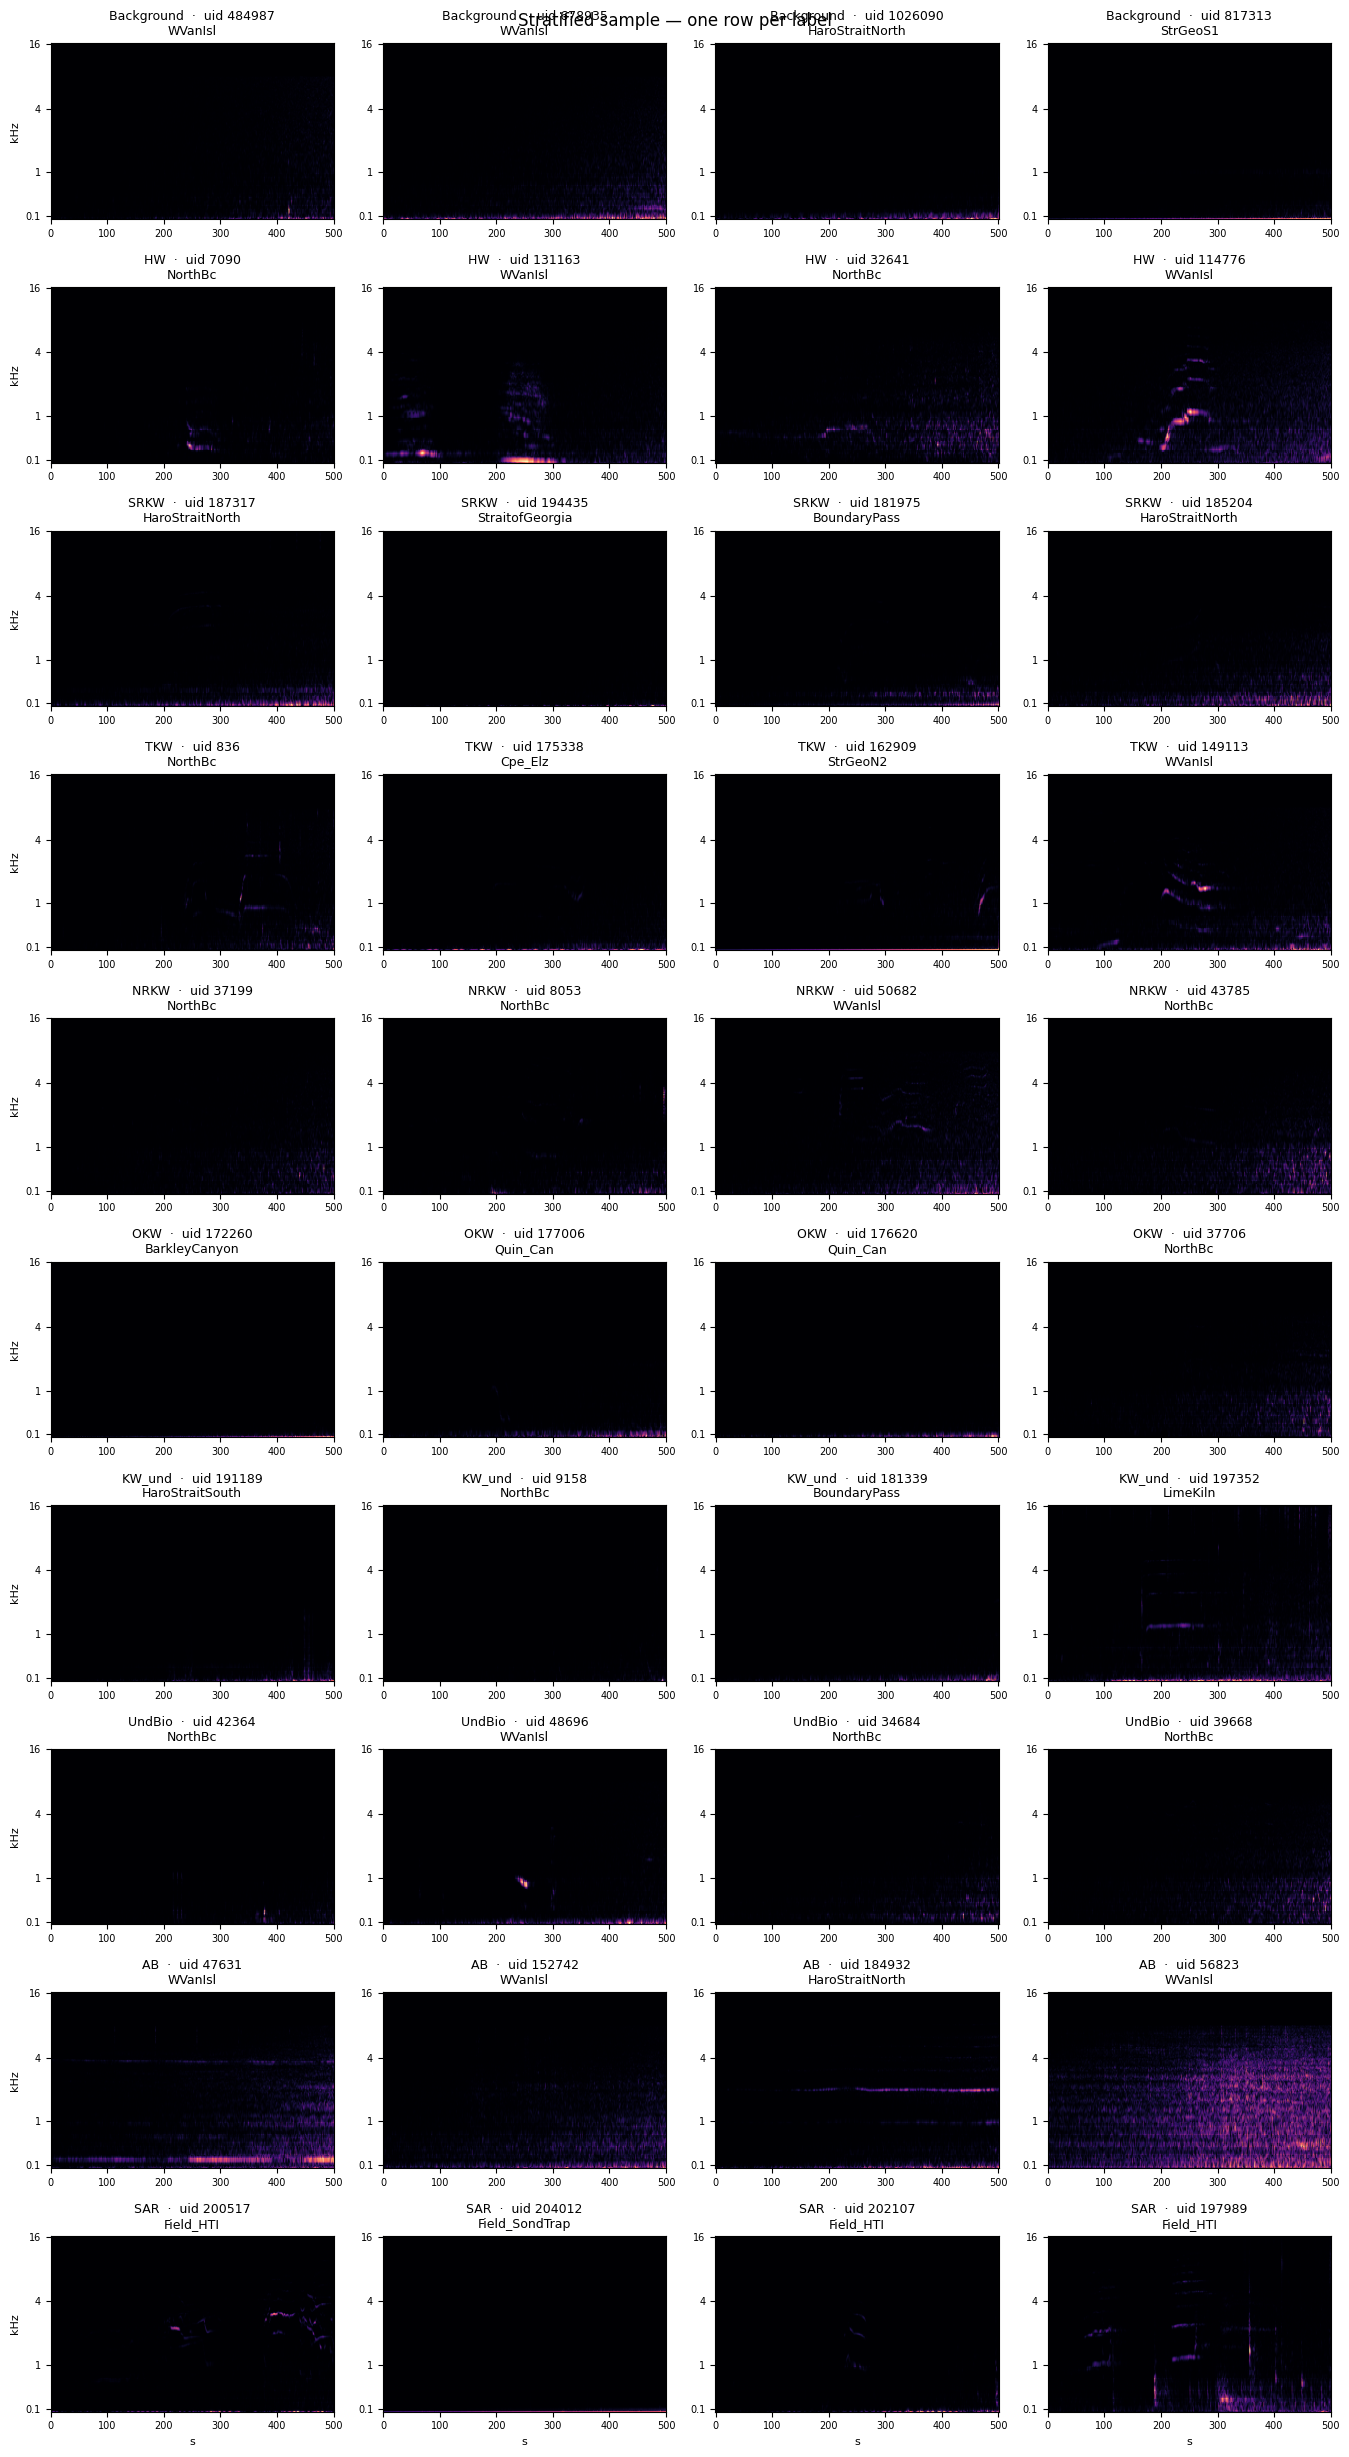

In [4]:
CLASS_ORDER = ["Background", "HW", "SRKW", "TKW", "NRKW", "OKW", "KW_und", "UndBio", "AB", "SAR"]
PER_CLASS = 4

stratified = np.concatenate([
    rng.choice(np.flatnonzero(meta["Labels"].values == label), PER_CLASS, replace=False)
    for label in CLASS_ORDER
])

plot_grid(stratified, n_cols=PER_CLASS, title="Stratified sample — one row per label")
plt.show()

## 4 · A random draw

No stratification: the natural class mix of the file (~84% `Background`).

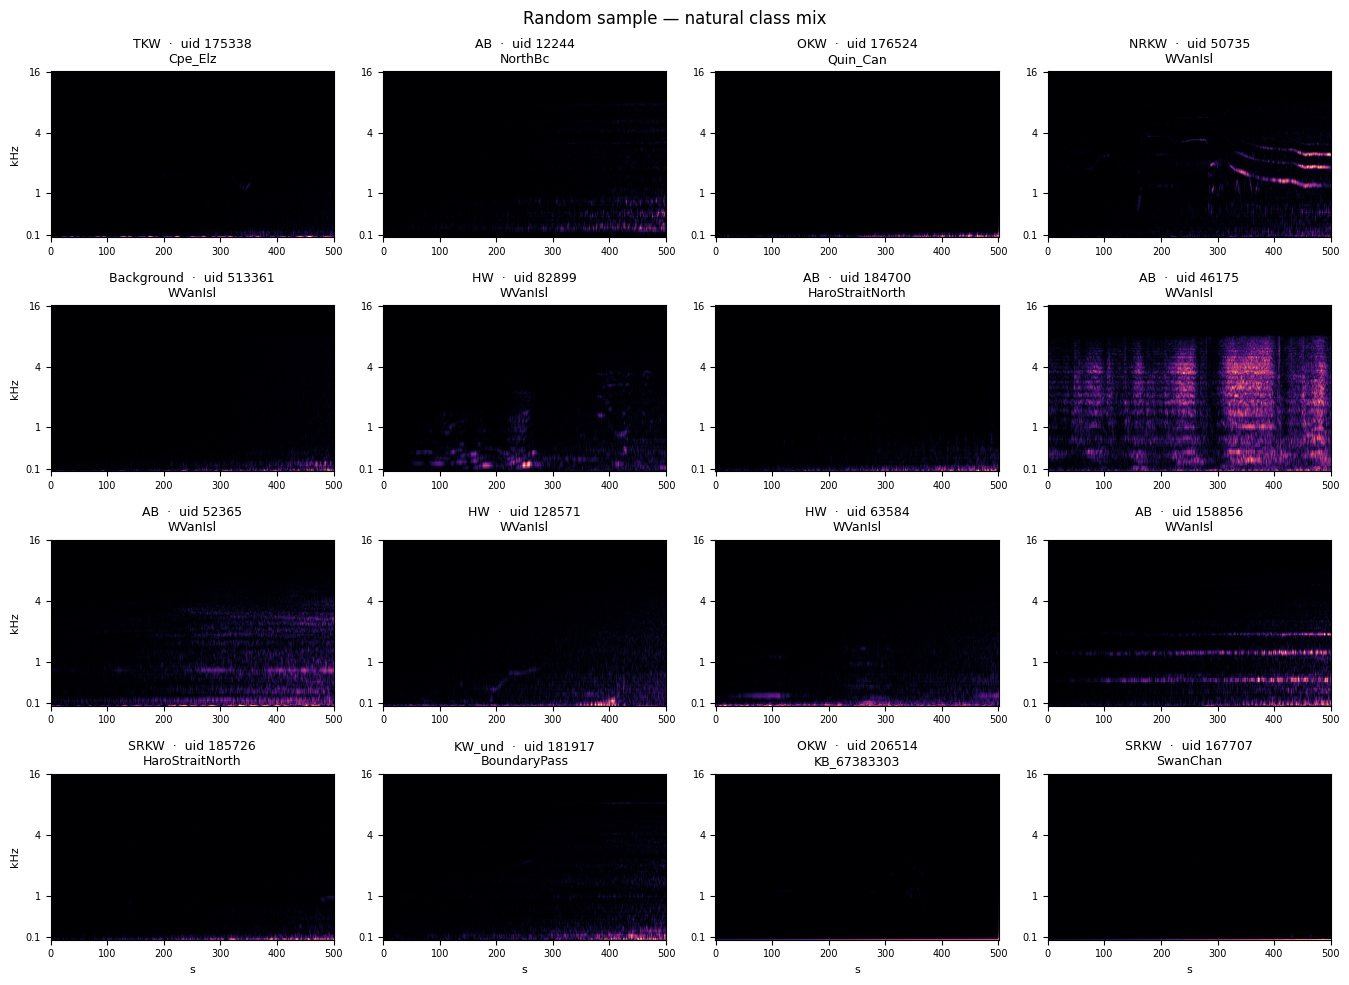

,uid,Labels,Dataset,BackgroundMethod,AnnotationLevel,Soundfile,FileBeginSec,Duration
60,12244,AB,NorthBc,nan,Detection,DFOCRP.KkHK0R2F-NML1.SM2M-3.20131120_233600Z.flac,157.200000,0.304000
214,46175,AB,WVanIsl,nan,Detection,DFOCRP.H50bjRcb-WCV1.AURAL117LF.20110612_21150...,91.249000,0.250000
257,50735,NRKW,WVanIsl,nan,Detection,DFOCRP.H50bjRcb-WCV1.AURAL117LF.20110816_05150...,51.203000,0.734000
271,52365,AB,WVanIsl,nan,Detection,DFOCRP.H50bjRcb-WCV1.AURAL117LF.20110907_12150...,135.015000,0.437000
300,63584,HW,WVanIsl,nan,Detection,DFOCRP.H50bjRcb-WCV1.AURAL117LF.20111130_22000...,198.405000,0.250000
311,82899,HW,WVanIsl,nan,Detection,DFOCRP.H50bjRcb-WCV1.AURAL117LF.20111208_13450...,69.078000,0.422000
351,128571,HW,WVanIsl,nan,Detection,DFOCRP.H50bjRcb-WCV1.AURAL117LF.20111230_05150...,125.765000,0.578000
404,158856,AB,WVanIsl,nan,Detection,DFOCRP.H50bjRcb-WCV1.AURAL117LF.20120524_16450...,240.608000,0.266000
445,167707,SRKW,SwanChan,nan,Detection,AMAR777.20211129T145245Z.wav,229.844000,0.341000
480,175338,TKW,Cpe_Elz,nan,Call,OCNMS13CE_110724_201917_CATransients.wav,468.691420,3.960396


In [5]:
random_rows = rng.choice(len(meta), 16, replace=False)

plot_grid(random_rows, n_cols=4, title="Random sample — natural class mix")
plt.show()

meta.iloc[sorted(random_rows)][["uid", "Labels", "Dataset", "BackgroundMethod", "AnnotationLevel",
                                "Soundfile", "FileBeginSec", "Duration"]]